In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/ubuntu22/4761-project/src")

from spatial_mrf.model_HMRF import AW_HMRF

import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad  
# processed and downloaded adata in MERFISH.ipynb
adata=sc.read_h5ad("/home/ubuntu22/4761-project/outputs/hmrf_label-parcellation_division_beta-20_K-15_init-kmeans_k-12_alpha-0p2_em-10_icm-5_seed-0/adata_with_hmrf.h5ad")

In [2]:
print(adata)

AnnData object with n_obs × n_vars = 36636 × 1122
    obs: 'brain_section_label', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'cluster_alias', 'x', 'y', 'z', 'subclass_confidence_score', 'cluster_confidence_score', 'high_quality_transfer', 'abc_sample_id', 'ccf_parcellation_index', 'parcellation_index', 'parcellation_division', 'parcellation_structure', 'parcellation_substructure', 'baseline_kmeans', 'baseline_kmeans_named', 'AW_HMRF_beta_20.0', 'AW_HMRF_beta_20.0_named'
    var: 'gene_symbol', 'mean', 'std'
    uns: 'AW_HMRF_beta_20.0_named_colors', 'baseline_kmeans_named_colors', 'neighbors', 'normalization', 'parcellation_division_colors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [ ]:
import scanpy as sc

# Calculate marker genes for each HMRF domain using Wilcoxon rank-sum test
sc.tl.rank_genes_groups(adata, 
                        groupby='AW_HMRF_beta_20.0_named', 
                        method='wilcoxon', 
                        key_added='rank_genes_aw_hmrf')

result_df = sc.get.rank_genes_groups_df(adata, group=None, key='rank_genes_aw_hmrf')
print("Top Marker Genes for each Domain:")
print(result_df.groupby('group').head(3))

Top Marker Genes for each Domain:
                         group               names     scores  logfoldchanges  \
0                        CTXsp  ENSMUSG00000070570  10.731709             NaN   
1                        CTXsp  ENSMUSG00000026249   8.841464             NaN   
2                        CTXsp  ENSMUSG00000074622   8.715232             NaN   
1122                       HPF  ENSMUSG00000059456  67.268005             NaN   
1123                       HPF  ENSMUSG00000038255  65.746078             NaN   
1124                       HPF  ENSMUSG00000026235  58.299614             NaN   
2244                        HY  ENSMUSG00000047507  77.037582             NaN   
2245                        HY  ENSMUSG00000018339  59.634403             NaN   
2246                        HY  ENSMUSG00000021032  54.580536             NaN   
3366                 Isocortex  ENSMUSG00000005583  98.269180             NaN   
3367                 Isocortex  ENSMUSG00000053025  91.517822             N

/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu22/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  se

In [ ]:
# Create a mapping dictionary from gene ID to gene symbol
id_to_symbol = dict(zip(adata.var.index, adata.var['gene_symbol']))

result_df['gene_symbol'] = result_df['names'].map(id_to_symbol)

print("Mapped Top Marker Genes:")
print(result_df.groupby('group').head(3)[['group', 'gene_symbol', 'scores']])

Mapped Top Marker Genes:
                         group gene_symbol     scores
0                        CTXsp     Slc17a7  10.731709
1                        CTXsp    Serpine2   8.841464
2                        CTXsp        Mafb   8.715232
1122                       HPF       Ptk2b  67.268005
1123                       HPF     Neurod2  65.746078
1124                       HPF       Epha4  58.299614
2244                        HY      Baiap3  77.037582
2245                        HY        Gpx3  59.634403
2246                        HY         Ngb  54.580536
3366                 Isocortex       Mef2c  98.269180
3367                 Isocortex        Sv2b  91.517822
3368                 Isocortex     Slc17a7  90.478455
4488                       OLF       Cldn5  27.586243
4489                       OLF         Fn1  24.462408
4490                       OLF        Tns1  24.372002
5610                       PAL       Fgf11  10.952553
5611                       PAL        Syt2  10.920696
561

/tmp/ipykernel_16554/3092290001.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(result_df.groupby('group').head(3)[['group', 'gene_symbol', 'scores']])


In [9]:
adata.var_names_make_unique() 
adata.var_names = adata.var['gene_symbol']

/tmp/ipykernel_16554/574562675.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_genes = result_df.groupby('group').head(2)['gene_symbol'].unique()


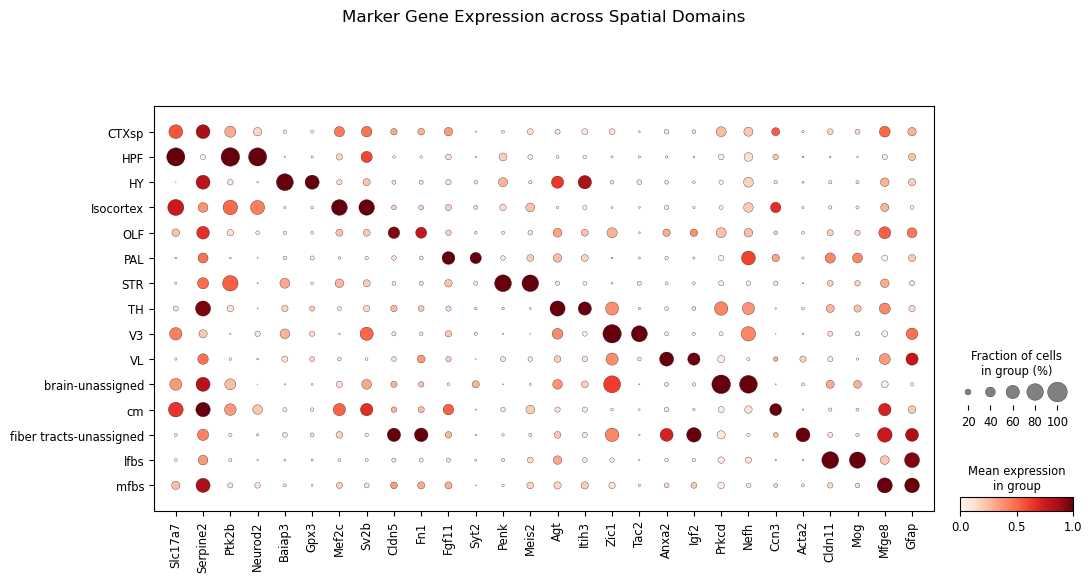

In [ ]:
# Select top2 genes for each region
top_genes = result_df.groupby('group').head(2)['gene_symbol'].unique()

sc.pl.dotplot(adata, 
              var_names=top_genes, 
              groupby='AW_HMRF_beta_20.0_named', 
              standard_scale='var', # 归一化，突出每个基因在哪个组表达最高
              title="Marker Gene Expression across Spatial Domains")

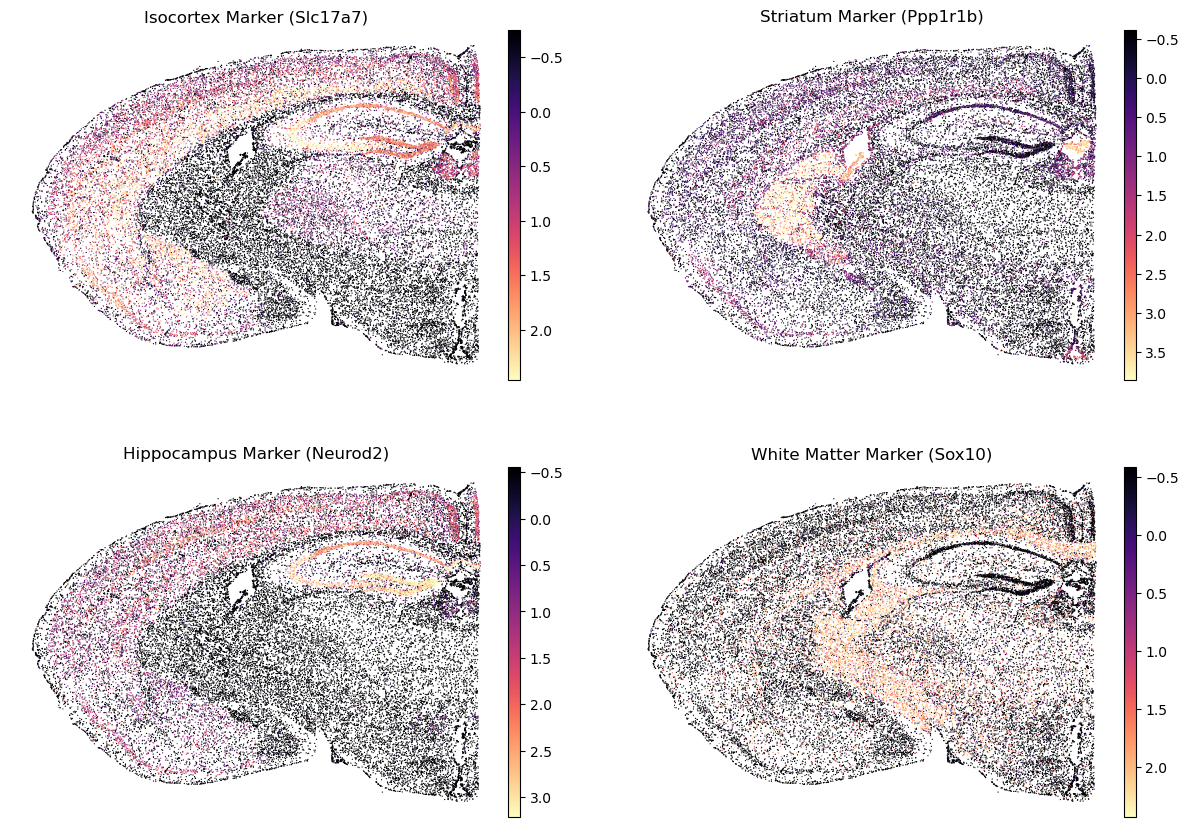

In [ ]:
import scanpy as sc

# Select 4 robust marker genes from the dataset
# 1. Slc17a7: marks excitatory neurons in Isocortex/CTXsp
# 2. Ppp1r1b: core marker for Striatum (STR)
# 3. Neurod2: key developmental marker for Hippocampus (HPF)
# 4. Sox10: identifies white matter (lfbs) and oligodendrocytes
selected_markers = ['Slc17a7', 'Ppp1r1b', 'Neurod2', 'Sox10']

# Verify all selected markers exist in the dataset

sc.pl.embedding(
    adata, 
    basis='spatial', 
    color=selected_markers,
    ncols=2, 
    frameon=False,
    vmax='p99', 
    cmap='magma',
    title=[ 
        'Isocortex Marker (Slc17a7)', 
        'Striatum Marker (Ppp1r1b)', 
        'Hippocampus Marker (Neurod2)',
        'White Matter Marker (Sox10)'
    ],
    show = False
)

fig = plt.gcf()

for ax in fig.axes:
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymax, ymin)   

plt.show()



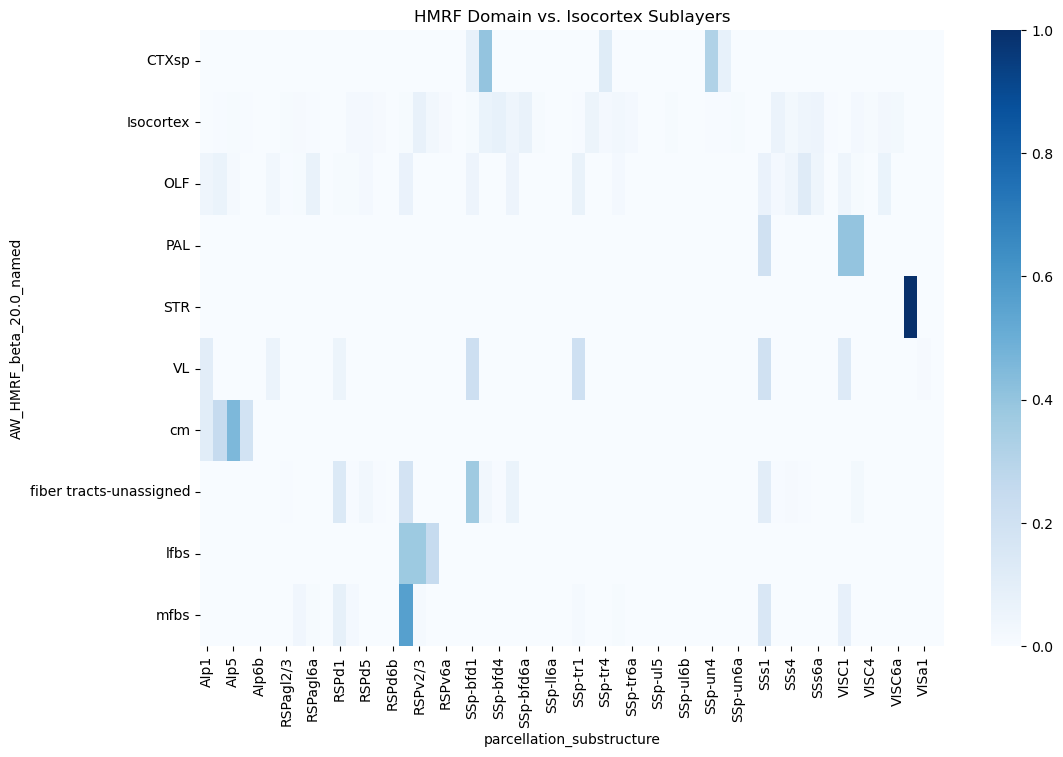

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 筛选出属于 Isocortex 的细胞
isocortex_mask = adata.obs['parcellation_division'] == 'Isocortex'
iso_adata = adata[isocortex_mask].copy()

# 计算 HMRF 结果与细分亚结构（层级）的重合比例
ct = pd.crosstab(iso_adata.obs['AW_HMRF_beta_20.0_named'], 
                 iso_adata.obs['parcellation_substructure'], 
                 normalize='index')

plt.figure(figsize=(12, 8))
sns.heatmap(ct, annot=False, cmap='Blues', fmt='.2f')
plt.title("HMRF Domain vs. Isocortex Sublayers")
plt.show()